In [1]:
import pandas as pd
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt



withdrawing and exploring of data

In [2]:
data=pd.read_csv("housing.csv",sep=",",header=0)
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [3]:
data.ocean_proximity.unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [4]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


filling null values (cleaning data)

In [6]:
data.total_bedrooms.median()

435.0

In [7]:
data=data.fillna(435.0)
# also i could use inplace=true (i will now for the future)
# data.to_excel("excel.xlsx")

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Splitting data to test and train

splitting test and train data

In [9]:
from sklearn.model_selection import train_test_split
X = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

In [11]:
train_data= X_train.join(y_train)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
4661,-118.30,34.05,44.0,1612.0,650.0,2028.0,593.0,1.9152,<1H OCEAN,115600.0
11428,-117.98,33.69,16.0,2437.0,438.0,986.0,422.0,5.7117,<1H OCEAN,247200.0
2800,-116.22,36.00,14.0,1372.0,386.0,436.0,213.0,1.1471,INLAND,32900.0
1235,-120.34,38.25,17.0,5497.0,1056.0,997.0,408.0,2.9821,INLAND,111500.0
13018,-121.20,38.69,26.0,3077.0,607.0,1603.0,595.0,2.7174,INLAND,137500.0
...,...,...,...,...,...,...,...,...,...,...
5258,-118.49,34.07,36.0,2929.0,366.0,1054.0,352.0,13.5728,<1H OCEAN,500001.0
15747,-122.44,37.78,52.0,2911.0,753.0,1696.0,676.0,2.5721,NEAR BAY,475000.0
9530,-123.10,38.97,36.0,1211.0,247.0,697.0,251.0,2.5761,<1H OCEAN,94900.0
14249,-117.09,32.72,39.0,1273.0,246.0,770.0,242.0,2.0938,NEAR OCEAN,102500.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

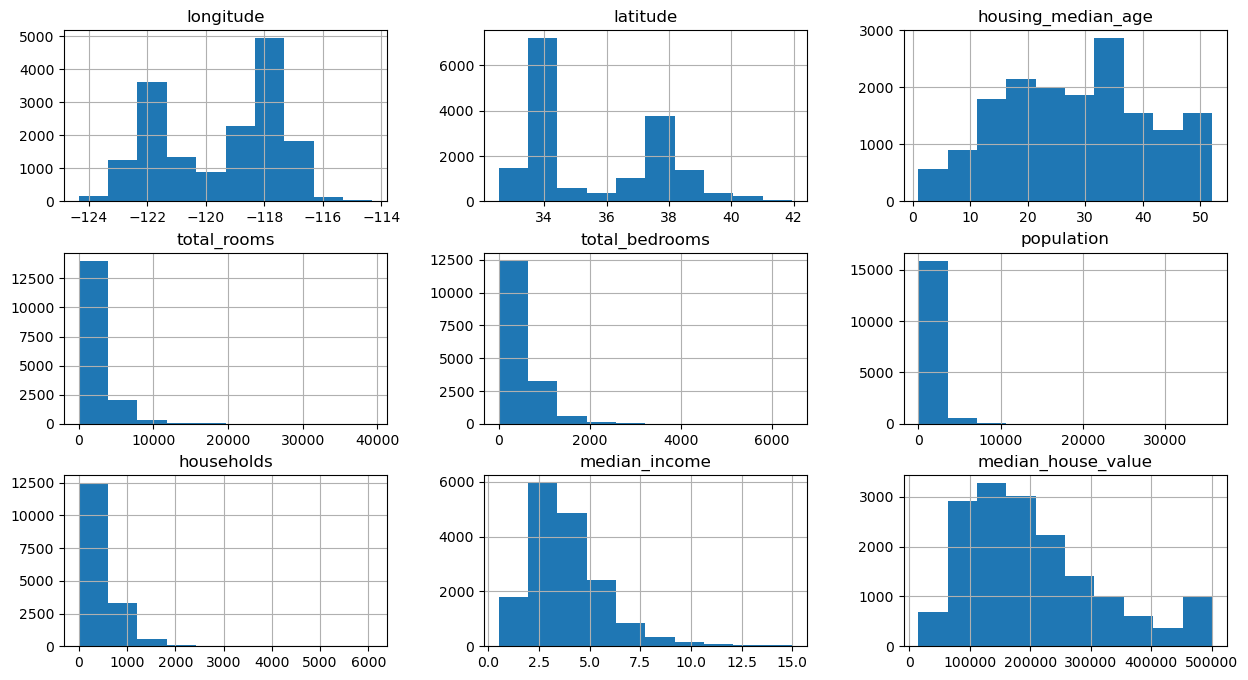

In [12]:
train_data.hist(figsize=(15,8))

creating correlation

<Axes: >

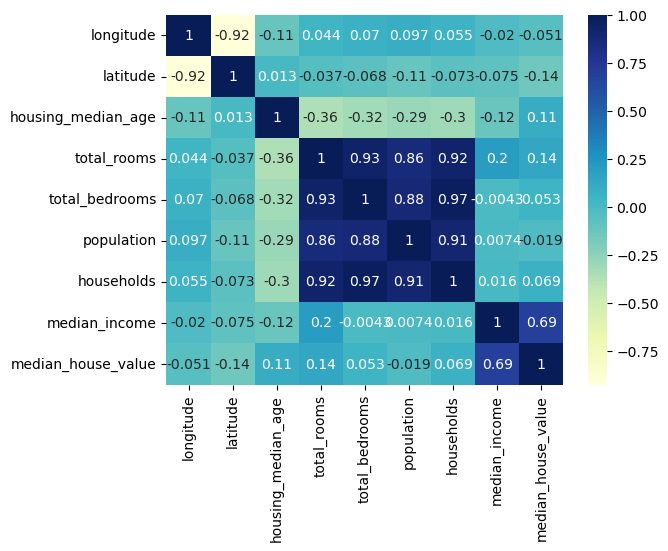

In [13]:
figsize=(15,8)
# train_data.corr(numeric_only=True)
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")


Fixing data so they would be more transparent on chart

In [14]:

train_data['total_rooms']=np.log(train_data['total_rooms']+1)
train_data['total_bedrooms']=np.log(train_data['total_bedrooms']+1)
train_data['population']=np.log(train_data['population']+1)
train_data['households']=np.log(train_data['households']+1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

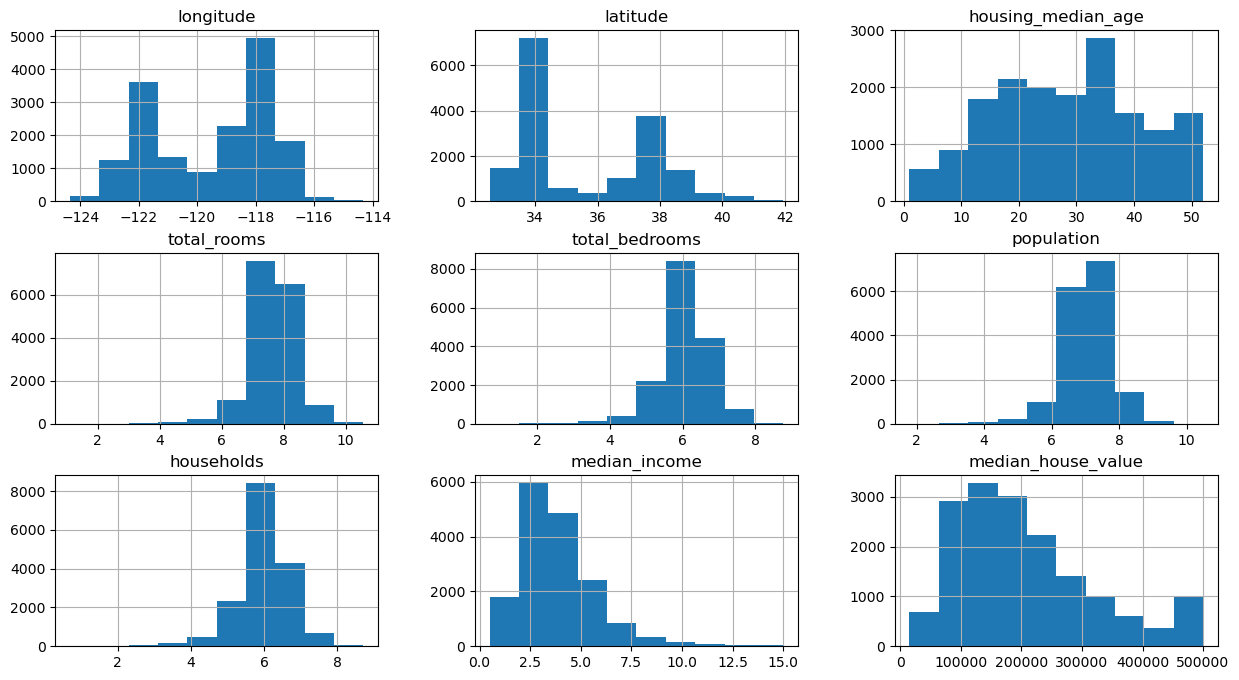

In [15]:
train_data.hist(figsize=(15,8))
# train_data['total_rooms']


and now in logharythmic scale, other bars are visable

Now, ocean_proximity will be fixed into usable values

In [16]:
# train_data["ocean_proximity"].unique()
train_data=train_data.join(pd.get_dummies(train_data['ocean_proximity'], dtype=int)).drop(['ocean_proximity'],axis=1)

In [17]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
4661,-118.30,34.05,44.0,7.385851,6.478510,7.615298,6.386879,1.9152,115600.0,1,0,0,0,0
11428,-117.98,33.69,16.0,7.798933,6.084499,6.894670,6.047372,5.7117,247200.0,1,0,0,0,0
2800,-116.22,36.00,14.0,7.224753,5.958425,6.079933,5.365976,1.1471,32900.0,0,1,0,0,0
1235,-120.34,38.25,17.0,8.612140,6.963190,6.905753,6.013715,2.9821,111500.0,0,1,0,0,0
13018,-121.20,38.69,26.0,8.032035,6.410175,7.380256,6.390241,2.7174,137500.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5258,-118.49,34.07,36.0,7.982758,5.905362,6.961296,5.866468,13.5728,500001.0,1,0,0,0,0
15747,-122.44,37.78,52.0,7.976595,6.625392,7.436617,6.517671,2.5721,475000.0,0,0,0,1,0
9530,-123.10,38.97,36.0,7.100027,5.513429,6.548219,5.529429,2.5761,94900.0,1,0,0,0,0
14249,-117.09,32.72,39.0,7.149917,5.509388,6.647688,5.493061,2.0938,102500.0,0,0,0,0,1


checking correlation

<Axes: >

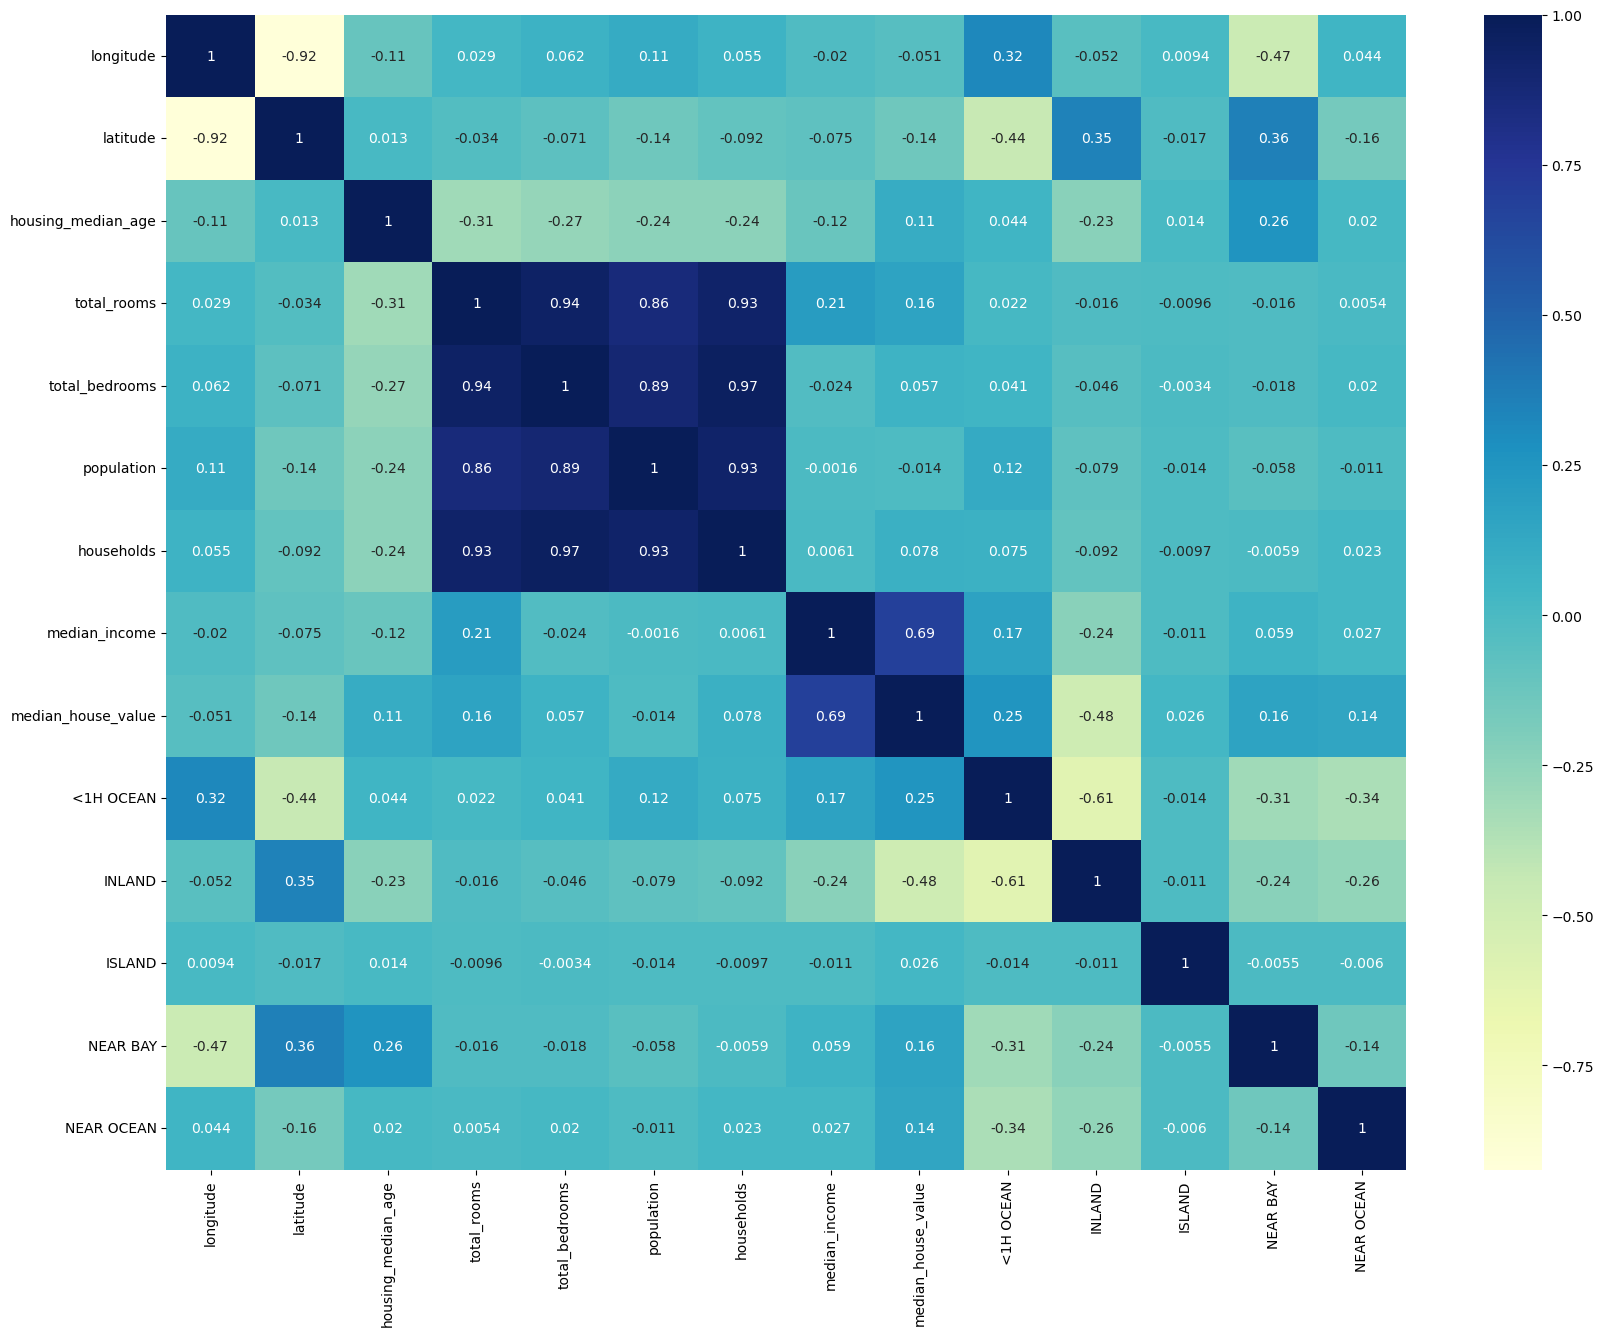

In [18]:

plt.figure(figsize=(20,15))
# train_data.corr(numeric_only=True)
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu" )

from heatmap it can be concluded if house is closer to sea the more expensive is it

that map, confirms it:

<Axes: xlabel='latitude', ylabel='longitude'>

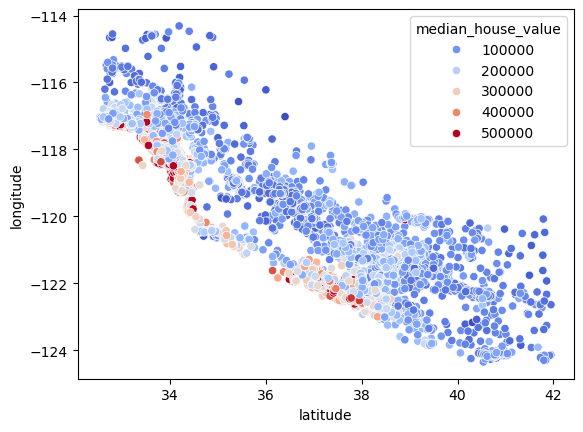

In [19]:
plt.Figure(figsize=(15,8))
sns.scatterplot(x='latitude',y='longitude', data=train_data, hue='median_house_value',palette='coolwarm')

In [20]:
train_data['bedroom_ratio']= train_data['total_bedrooms']/train_data['total_rooms']
train_data['household_rooms']= train_data['total_rooms']/train_data['households']

<Axes: >

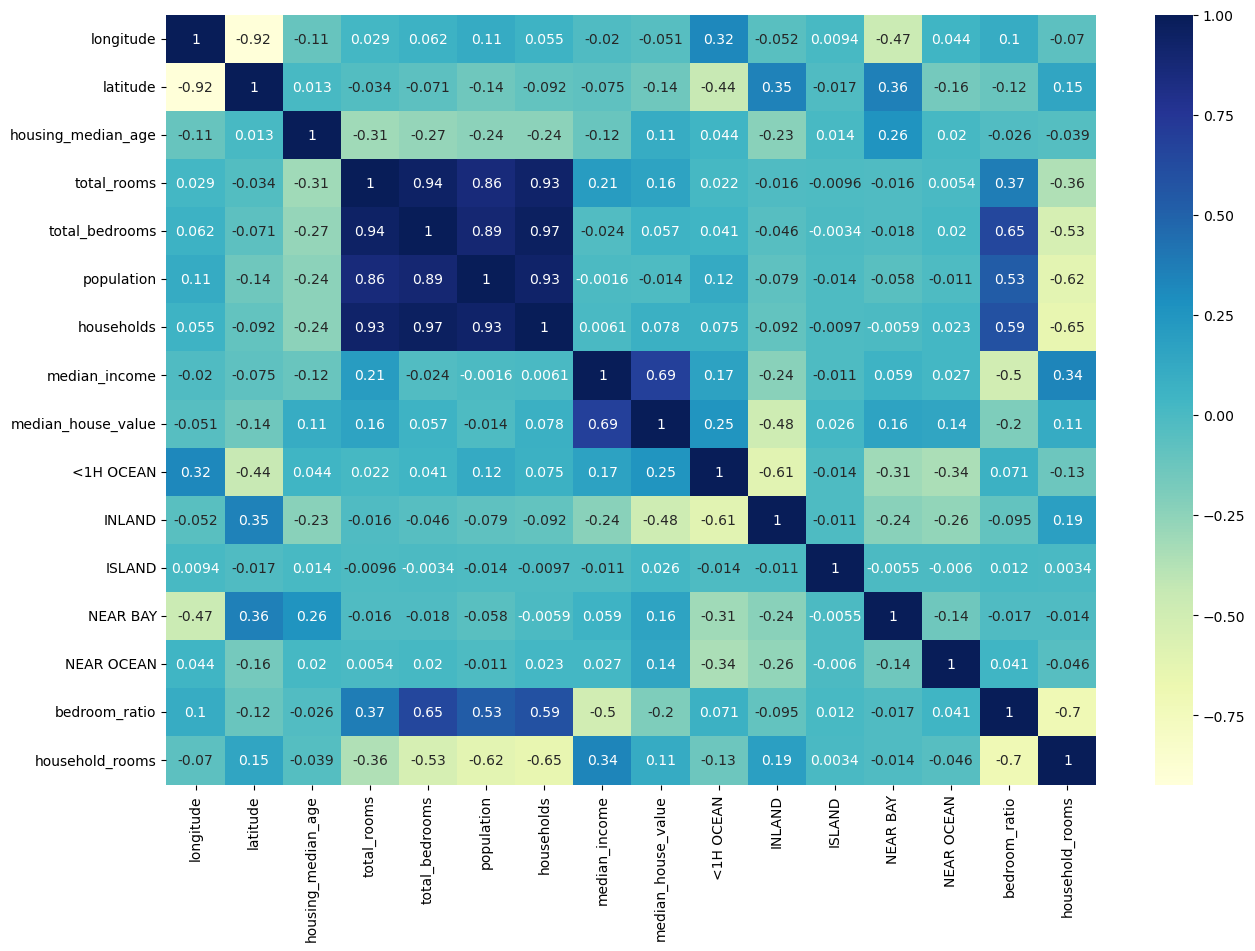

In [21]:
plt.figure(figsize=(15,10))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu" )

bedroom ratio to total rooms not really tells anything about median house value but household_rooms does

linear regression:

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train,y_train= train_data.drop( ['median_house_value'], axis=1), train_data['median_house_value']
X_train_s = scaler.fit_transform(X_train)
reg = LinearRegression()
reg.fit(X_train_s,y_train)

LinearRegression()

In [23]:
test_data= X_test.join(y_test)

test_data['total_rooms']=np.log(test_data['total_rooms']+1)
test_data['total_bedrooms']=np.log(test_data['total_bedrooms']+1)
test_data['population']=np.log(test_data['population']+1)
test_data['households']=np.log(test_data['households']+1)

test_data=test_data.join(pd.get_dummies(test_data['ocean_proximity'], dtype=int)).drop(['ocean_proximity'],axis=1)

test_data['bedroom_ratio']= test_data['total_bedrooms']/test_data['total_rooms']
test_data['household_rooms']= test_data['total_rooms']/test_data['households']


In [24]:
X_test,y_test= test_data.drop(['median_house_value'], axis=1), test_data['median_house_value']

In [25]:
# test_data.drop(['ISLAND'], inplace=True, axis=1)

In [26]:
# reg.score(X_test,y_test)
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,household_rooms
3734,-118.40,34.19,30.0,6.257668,4.844187,5.726848,4.867534,4.1125,216700.0,1,0,0,0,0,0.774120,1.285593
1712,-122.32,37.97,29.0,7.761319,6.142037,7.035269,6.196444,3.9722,161000.0,0,0,0,1,0,0.791365,1.252544
19977,-118.70,35.82,20.0,8.443116,7.170888,6.490724,5.513429,2.3937,82100.0,0,1,0,0,0,0.849318,1.531373
20033,-119.02,36.07,29.0,7.867489,6.393591,7.414573,6.349139,1.5911,60800.0,0,1,0,0,0,0.812660,1.239143
5851,-118.32,34.18,44.0,7.374629,5.966147,6.725034,5.831882,3.4000,212100.0,1,0,0,0,0,0.809010,1.264537
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4959,-118.29,34.01,50.0,7.713785,6.513230,7.717796,6.369901,1.6505,125000.0,1,0,0,0,0,0.844362,1.210974
20040,-118.99,36.07,21.0,6.891626,5.111988,6.511745,5.135798,2.9750,63900.0,0,1,0,0,0,0.741768,1.341880
16072,-122.49,37.75,48.0,7.778211,6.052089,6.948897,6.013715,3.7562,321200.0,0,0,0,0,1,0.778082,1.293412
15274,-117.27,33.06,7.0,8.212568,6.598509,7.385851,6.511745,3.1970,367100.0,0,0,0,0,1,0.803465,1.261193


In [27]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,household_rooms
4661,-118.30,34.05,44.0,7.385851,6.478510,7.615298,6.386879,1.9152,115600.0,1,0,0,0,0,0.877151,1.156410
11428,-117.98,33.69,16.0,7.798933,6.084499,6.894670,6.047372,5.7117,247200.0,1,0,0,0,0,0.780171,1.289640
2800,-116.22,36.00,14.0,7.224753,5.958425,6.079933,5.365976,1.1471,32900.0,0,1,0,0,0,0.824724,1.346401
1235,-120.34,38.25,17.0,8.612140,6.963190,6.905753,6.013715,2.9821,111500.0,0,1,0,0,0,0.808532,1.432083
13018,-121.20,38.69,26.0,8.032035,6.410175,7.380256,6.390241,2.7174,137500.0,0,1,0,0,0,0.798076,1.256922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5258,-118.49,34.07,36.0,7.982758,5.905362,6.961296,5.866468,13.5728,500001.0,1,0,0,0,0,0.739765,1.360743
15747,-122.44,37.78,52.0,7.976595,6.625392,7.436617,6.517671,2.5721,475000.0,0,0,0,1,0,0.830604,1.223841
9530,-123.10,38.97,36.0,7.100027,5.513429,6.548219,5.529429,2.5761,94900.0,1,0,0,0,0,0.776536,1.284043
14249,-117.09,32.72,39.0,7.149917,5.509388,6.647688,5.493061,2.0938,102500.0,0,0,0,0,1,0.770553,1.301627


In [28]:
X_test_s=scaler.transform(X_test)

In [29]:
reg.score(X_test_s,y_test)

0.6546073837129647

0.6522422545210829 without scaller 
0.6546073837129647 with scaller
forest model:

In [32]:
from sklearn.ensemble import RandomForestRegressor
forest= RandomForestRegressor()
forest.fit(X_train_s, y_train)

RandomForestRegressor()

In [33]:
forest.score(X_test_s,y_test)

0.8072780545711395

without scaller: 0.8055328689153156
with scaller: 0.8072780545711395
grid forest model:

In [34]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [3,10,30],
    "max_features": [2,4,6,8]
}
grid_search=GridSearchCV(forest, param_grid, cv=5, scoring="neg_mean_squared_error", return_train_score=True)
grid_search.fit(X_train_s,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_features': [2, 4, 6, 8],
                         'n_estimators': [3, 10, 30]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [39]:
best_forest=grid_search.best_estimator_
best_forest

RandomForestRegressor(max_features=8, n_estimators=30)

In [38]:
best_forest.score(X_test_s,y_test)

0.803590249141962

current output: 0.803590249141962
best estimator is 8 and 30 so i will if it can be improved

In [40]:
param_grid = {
    "n_estimators": [30,50,70],
    "max_features": [8,12,16]
}
grid_search=GridSearchCV(forest, param_grid, cv=5, scoring="neg_mean_squared_error", return_train_score=True)
grid_search.fit(X_train_s,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_features': [8, 12, 16],
                         'n_estimators': [30, 50, 70]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [43]:
second_best_forest=grid_search.best_estimator_

In [45]:
second_best_forest.score(X_test_s,y_test)

0.8069968545575269

old one: 0.803590249141962
second_best: 0.8069968545575269
i'm afriad it's not worth it

In [ ]:
param_grid = {
    "n_estimators": [70,80],
    "max_features": [11,12,13],
    "min_samples_split": [2,4],
    "max_depth": [None,4,8]
}
grid_search=GridSearchCV(forest, param_grid, cv=5, scoring="neg_mean_squared_error", return_train_score=True)
grid_search.fit(X_train_s,y_train)

c:\Users\pawel\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
60 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\pawel\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\pawel\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "c:\Users\pawel\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "c:\Users\pawel\anaconda3\Lib\site-packages

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [0, 4, 8], 'max_features': [11, 12, 13],
                         'min_samples_split': [2, 4],
                         'n_estimators': [70, 80]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [48]:
third_best_tree=grid_search.best_estimator_
third_best_tree.score(X_test_s,y_test)

0.7373619752495038

third: 0.7373619752495038
Well i overfitted the model i guess
